


# ============================================================
# MODEL / EXPERIMENT CONFIGURATION
Final 15 min Model
# ============================================================
resample_freq = "15min"

train_ratio = 0.70

val_ratio = 0.15

test_ratio = 0.15

target_col = "scd41_co2"

history_days = 60 input

forecast_hours = 15 min

batch_size = 64

num_epochs = 15

d_model=32

nhead=4,

num_layers=1,

dim_feedforward=64,

dropout=0.2

lr=0.0003




In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [111]:
df = pd.read_csv("../../data/indoorAir2.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort by station and time
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Remove Station id 6
df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()

resample_freq = "15min"

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df["timestamp"] = pd.to_datetime(feature_df["timestamp"])

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df["hour"] = feature_df["timestamp"].dt.hour + feature_df["timestamp"].dt.minute / 60
feature_df["dayofweek"] = feature_df["timestamp"].dt.dayofweek

feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df["hour"] / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df["hour"] / 24)

feature_df["dayofweek_sin"] = np.sin(2 * np.pi * feature_df["dayofweek"] / 7)
feature_df["dayofweek_cos"] = np.cos(2 * np.pi * feature_df["dayofweek"] / 7)

feature_df["is_weekend"] = feature_df["dayofweek"].isin([5, 6]).astype(int)

feature_df = feature_df.drop(columns=["hour", "dayofweek"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186889, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [113]:
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df["next_timestamp"] = (
    feature_df
    .groupby("station_id")["timestamp"]
    .shift(-1)
)

feature_df["next_gap"] = feature_df["next_timestamp"] - feature_df["timestamp"]

feature_df = feature_df[
    feature_df["next_gap"].between(
        pd.Timedelta(minutes=13),
        pd.Timedelta(minutes=17)
    )
].copy()

feature_df = feature_df.drop(columns=["next_timestamp", "next_gap"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [114]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [115]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

outlier_bounds = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).sum(),
        "outlier_percent_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).mean() * 100
    }

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_bounds).T
print(outlier_df)
print(feature_df.shape)
feature_df.head()

                        lower_bound   upper_bound  outlier_count_before  \
ens160_aqi            -5.000000e-01  3.500000e+00                2125.0   
ens160_tvoc           -9.768571e+01  2.889048e+02               18971.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07                   0.0   
bme688_pressure        9.849031e+01  1.018882e+02                7020.0   
scd41_temperature      1.971432e+01  2.910343e+01                3303.0   
scd41_humidity         8.847241e+00  6.352849e+01                  86.0   
scd41_co2              2.501637e+02  7.448383e+02               18972.0   

                       outlier_percent_before  
ens160_aqi                           1.137069  
ens160_tvoc                         10.151217  
bme688_gas_resistance                0.000000  
bme688_pressure                      3.756341  
scd41_temperature                    1.767407  
scd41_humidity                       0.046018  
scd41_co2                           10.151752  
(186884, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:45:00,1.0,35.000000,12946860.0,100.564571,22.546857,37.827555,483.333333,-0.946930,-0.321439,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.564571,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0
2,1,2024-11-13 17:15:00,1.0,26.852154,12946860.0,100.564571,22.759797,37.636283,471.997279,-0.980785,-0.195090,0.974928,-0.222521,0
3,1,2024-11-13 17:30:00,1.0,26.847166,12946860.0,100.564571,22.773352,37.668370,471.708844,-0.991445,-0.130526,0.974928,-0.222521,0
4,1,2024-11-13 17:45:00,1.0,26.842177,12946860.0,100.564571,22.786907,37.700458,471.420408,-0.997859,-0.065403,0.974928,-0.222521,0


In [116]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  


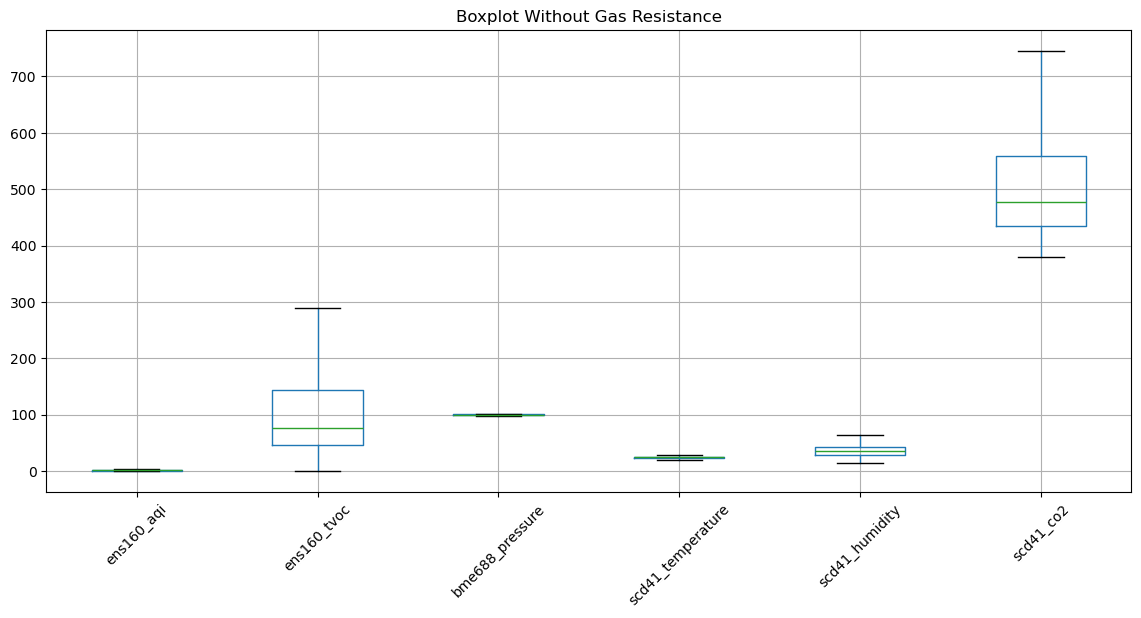

In [117]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [118]:
# ==========================================
# Step 8 - Time-Based Split
# ==========================================

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (130816, 14)
Val shape: (28031, 14)
Test shape: (28037, 14)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381


In [119]:
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col not in ["timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Input features:", feature_cols)
print("Past CO2 included:", target_col in feature_cols)
print("Scaled X train min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y train min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
Past CO2 included: True
Scaled X train min/max: 0.0 1.0000000000000002
Scaled y train min/max: 0.0 1.0000000000000002


In [120]:
input_size = 60   # 60 rows * 15 min = past 15 hours
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col != "timestamp"
]

def create_windows(data, feature_cols, target_col):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        # X uses previous 60 timestamps, y uses next timestamp
        # Since data is 15-min sampled, y[i] = CO2 15 min ahead
        for i in range(input_size, len(station_data)):
            X_windows.append(X[i - input_size:i])
            y_windows.append(y[i])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (130516, 60, 13) y_train: (130516,)
X_val: (27731, 60, 13) y_val: (27731,)
X_test: (27737, 60, 13) y_test: (27737,)


In [121]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 2040
Val batches: 434
Test batches: 434


In [ ]:
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        num_features,
        #d_model=32,
        #nhead=4,
        #num_layers=1,
        d_model = 64,
        nhead = 4,
        num_layers = 2,
        dim_feedforward=64,
        dropout=0.2,
        max_len=input_size
    ):
        super().__init__()

        self.input_projection = nn.Linear(num_features, d_model)

        self.positional_embedding = nn.Parameter(
            torch.zeros(1, max_len, d_model)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        seq_len = x.size(1)

        x = self.input_projection(x)
        x = x + self.positional_embedding[:, :seq_len, :]

        x = self.transformer_encoder(x)

        # Use last time step representation
        #x = x[:, -1, :]
        x = x.mean(dim=1)
        output = self.regressor(x)
        return output

In [123]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_features = X_train.shape[2]

model = TransformerRegressor(
    num_features=num_features,
    d_model=32,
    nhead=4,
    num_layers=1,
    dim_feedforward=64,
    dropout=0.2,
    max_len=input_size
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

Device: cpu


In [124]:
num_epochs = 15
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_transformer_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/15] Train Loss: 0.016647 Val Loss: 0.004461
Epoch [2/15] Train Loss: 0.003274 Val Loss: 0.003040
Epoch [3/15] Train Loss: 0.002620 Val Loss: 0.001576
Epoch [4/15] Train Loss: 0.002318 Val Loss: 0.001641
Epoch [5/15] Train Loss: 0.002195 Val Loss: 0.001504
Epoch [6/15] Train Loss: 0.002117 Val Loss: 0.001999
Epoch [7/15] Train Loss: 0.002077 Val Loss: 0.001533
Epoch [8/15] Train Loss: 0.002045 Val Loss: 0.001531
Epoch [9/15] Train Loss: 0.002032 Val Loss: 0.001414
Epoch [10/15] Train Loss: 0.002005 Val Loss: 0.001400
Epoch [11/15] Train Loss: 0.002000 Val Loss: 0.001365
Epoch [12/15] Train Loss: 0.001980 Val Loss: 0.001381
Epoch [13/15] Train Loss: 0.001991 Val Loss: 0.001332
Epoch [14/15] Train Loss: 0.001952 Val Loss: 0.001289
Epoch [15/15] Train Loss: 0.001947 Val Loss: 0.001304


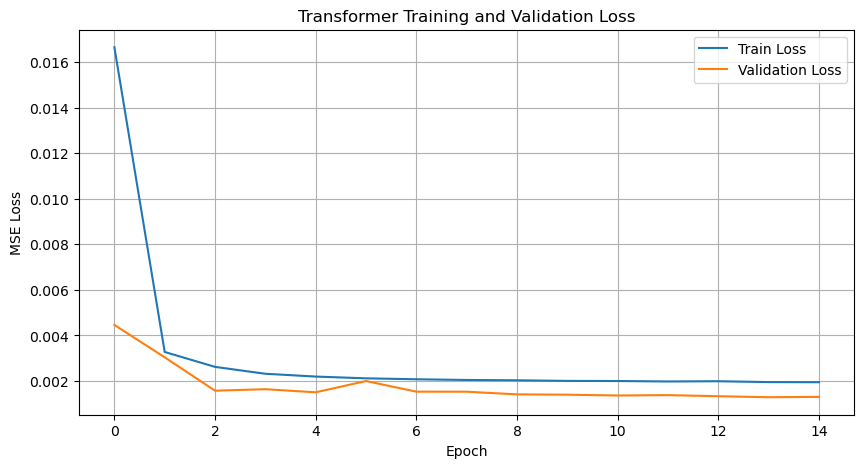

In [125]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [126]:

model.load_state_dict(torch.load("best_transformer_model.pth", map_location=device))
model.eval()

y_true_scaled = []
y_pred_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        preds = model(X_batch).cpu().numpy()

        y_pred_scaled.extend(preds)
        y_true_scaled.extend(y_batch.numpy())

y_true_scaled = np.array(y_true_scaled)
y_pred_scaled = np.array(y_pred_scaled)

y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Test MSE: 70.73151397705078
Test RMSE: 8.410202968837957
Test MAE: 3.8911983966827393
Test R2: 0.9941089153289795


In [127]:
# =====================
# Normalized Metrics
# =====================

mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print("=== Normalized Scale ===")
print("MSE :", mse_scaled)
print("RMSE:", rmse_scaled)
print("MAE :", mae_scaled)
print("R²  :", r2_scaled)

# =====================
# Original Scale
# =====================

y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n=== Original Scale ===")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

=== Normalized Scale ===
MSE : 0.0005299350596033037
RMSE: 0.02302031840794787
MAE : 0.010650943964719772
R²  : 0.9941089153289795

=== Original Scale ===
MSE : 70.73151397705078
RMSE: 8.410202968837957
MAE : 3.8911983966827393
R²  : 0.9941089153289795


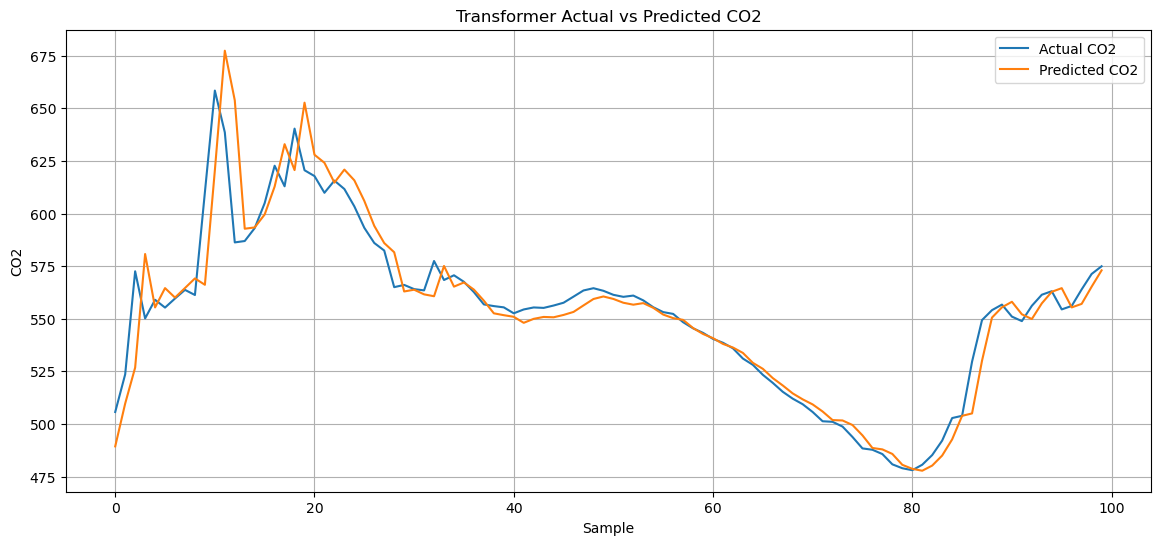

In [128]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual CO2")
plt.plot(y_pred[:100], label="Predicted CO2")
plt.xlabel("Sample")
plt.ylabel("CO2")
plt.title("Transformer Actual vs Predicted CO2")
plt.legend()
plt.grid(True)
plt.show()

#  Explainability Analysis

Understanding why a model makes a prediction is important for building trust and interpreting forecasting results. Therefore, explainability techniques were applied to investigate which input variables contributed most to the Transformer's predictions.

This study uses Feature Ablation Analysis, where each feature is removed individually and the impact on forecasting performance is measured. Features causing the largest degradation in performance are considered the most important for the prediction task.

## 1 Feature Ablation Analysis

To understand the contribution of each input variable to the Transformer's forecasting performance, a feature ablation study was conducted.

In this analysis, one feature was removed at a time by replacing its values with zeros in the test dataset while keeping the trained model unchanged. The resulting increase in prediction error was used to quantify the importance of each feature.

Features that cause a larger degradation in model performance are considered more influential for forecasting future indoor CO₂ concentrations.

In [129]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_scaled)
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 0.02302031840794787


## Run Feature Ablation


In [130]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error

ablation_results = []

for feature_idx, feature_name in enumerate(feature_cols):

    # Copy test data
    X_test_ablation = X_test.copy()

    # Remove one feature
    X_test_ablation[:, :, feature_idx] = 0

    # Convert to tensor
    X_test_ablation_tensor = torch.tensor(
        X_test_ablation,
        dtype=torch.float32
    ).to(device)

    # Predict
    model.eval()

    with torch.no_grad():
        ablated_pred = model(X_test_ablation_tensor)

    ablated_pred = ablated_pred.cpu().numpy().flatten()

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            ablated_pred
        )
    )

    ablation_results.append([
        feature_name,
        rmse,
        rmse - baseline_rmse
    ])

ablation_df = pd.DataFrame(
    ablation_results,
    columns=[
        "Feature",
        "RMSE",
        "RMSE Increase"
    ]
)

ablation_df = ablation_df.sort_values(
    "RMSE Increase",
    ascending=False
)

ablation_df.reset_index(drop=True, inplace=True)

ablation_df

,Feature,RMSE,RMSE Increase
0,scd41_co2,0.455706,0.432686
1,hour_sin,0.107214,0.084193
2,hour_cos,0.058371,0.035350
3,station_id,0.027089,0.004068
4,scd41_humidity,0.026330,0.003309
5,bme688_gas_resistance,0.026125,0.003105
6,bme688_pressure,0.024429,0.001408
7,scd41_temperature,0.024154,0.001134
8,dayofweek_sin,0.023673,0.000653
9,ens160_aqi,0.023339,0.000319


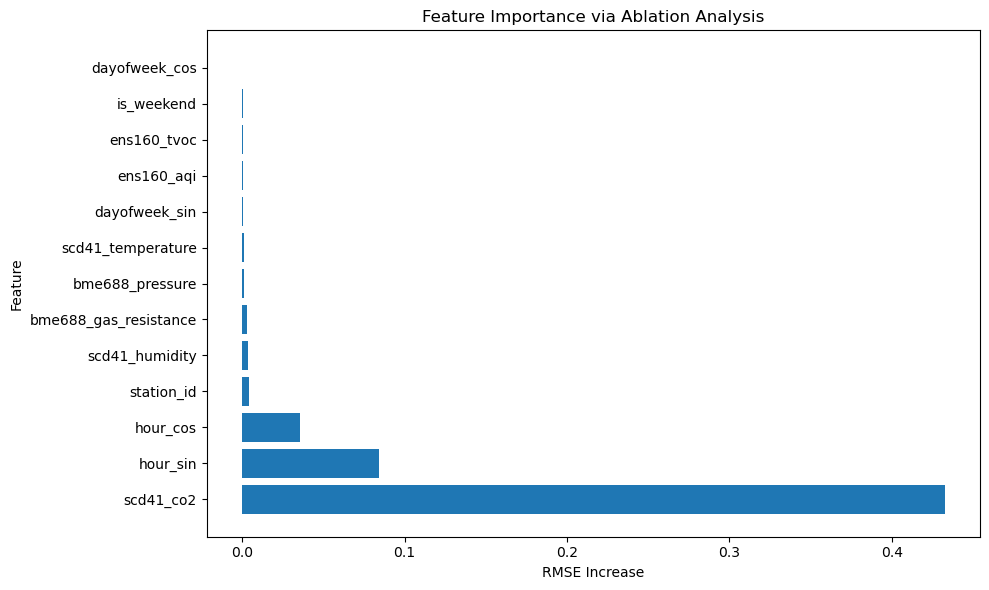

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    ablation_df["Feature"],
    ablation_df["RMSE Increase"]
)

plt.xlabel("RMSE Increase")
plt.ylabel("Feature")
plt.title("Feature Importance via Ablation Analysis")

plt.tight_layout()
plt.show()

In [132]:
ablation_df["Importance (%)"] = (
    ablation_df["RMSE Increase"] /
    ablation_df["RMSE Increase"].sum()
) * 100

ablation_df

,Feature,RMSE,RMSE Increase,Importance (%)
0,scd41_co2,0.455706,0.432686,76.377486
1,hour_sin,0.107214,0.084193,14.861751
2,hour_cos,0.058371,0.035350,6.240034
3,station_id,0.027089,0.004068,0.718159
4,scd41_humidity,0.026330,0.003309,0.584181
5,bme688_gas_resistance,0.026125,0.003105,0.548065
6,bme688_pressure,0.024429,0.001408,0.248624
7,scd41_temperature,0.024154,0.001134,0.200150
8,dayofweek_sin,0.023673,0.000653,0.115210
9,ens160_aqi,0.023339,0.000319,0.056340


## 1.2 Permutation Feature Importance

While feature ablation removes a feature completely, permutation feature importance evaluates feature relevance by randomly shuffling feature values across samples. This preserves the original feature distribution while breaking its relationship with the target variable.

A larger increase in prediction error after permutation indicates a greater contribution of the feature to forecasting performance.

In [133]:
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error

perm_results = []

for feature_idx, feature_name in enumerate(feature_cols):

    X_perm = X_test.copy()

    # Shuffle feature values across samples
    shuffled_values = X_perm[:, :, feature_idx].copy()

    np.random.shuffle(shuffled_values)

    X_perm[:, :, feature_idx] = shuffled_values

    X_perm_tensor = torch.tensor(
        X_perm,
        dtype=torch.float32
    ).to(device)

    model.eval()

    with torch.no_grad():
        perm_pred = model(X_perm_tensor)

    perm_pred = perm_pred.cpu().numpy().flatten()

    perm_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            perm_pred
        )
    )

    perm_results.append([
        feature_name,
        perm_rmse,
        perm_rmse - baseline_rmse
    ])

perm_df = pd.DataFrame(
    perm_results,
    columns=[
        "Feature",
        "RMSE",
        "RMSE Increase"
    ]
)

perm_df = perm_df.sort_values(
    "RMSE Increase",
    ascending=False
)

perm_df.reset_index(drop=True, inplace=True)

perm_df

,Feature,RMSE,RMSE Increase
0,scd41_co2,0.420824,0.397803
1,hour_sin,0.044852,0.021831
2,hour_cos,0.043678,0.020658
3,station_id,0.025572,0.002552
4,bme688_gas_resistance,0.024650,0.001630
5,scd41_temperature,0.023566,0.000546
6,dayofweek_sin,0.023550,0.000530
7,is_weekend,0.023536,0.000516
8,scd41_humidity,0.023391,0.000370
9,bme688_pressure,0.023199,0.000179


Both feature ablation and permutation feature importance identified historical CO₂ concentration (scd41_co2) as the dominant predictor for future CO₂ forecasting.

In both analyses, removing or perturbing the CO₂ feature caused a substantially larger increase in prediction error than any other input variable. This indicates that the Transformer relies primarily on historical CO₂ observations to model future concentrations.

Environmental variables such as AQI, TVOC, temperature, and humidity exhibited comparatively small contributions. This suggests that these variables provide supplementary contextual information, while the temporal evolution of CO₂ itself remains the primary source of predictive information.

The agreement between feature ablation and permutation importance strengthens confidence in the robustness of these findings.

## Teq 2: Temporal Attention Analysis

To understand how the Transformer utilizes historical observations when forecasting future CO₂ concentrations, attention weights were extracted from the self-attention mechanism of the Transformer encoder.

Attention scores indicate the relative importance assigned to different historical timesteps during prediction. Higher attention values imply that the model considers those observations more influential when generating forecasts.

## Extract Attention Weights

In [134]:
sample_idx = 0

x_sample = torch.tensor(
    X_test[sample_idx:sample_idx+1],
    dtype=torch.float32
).to(device)

model.eval()

with torch.no_grad():

    x = model.input_projection(x_sample)

    seq_len = x.shape[1]

    x = x + model.positional_embedding[:, :seq_len, :]

    attention_output, attention_weights = (
        model.transformer_encoder.layers[0].self_attn(
            x,
            x,
            x,
            need_weights=True,
            average_attn_weights=False
        )
    )

print("Attention Shape:", attention_weights.shape)

Attention Shape: torch.Size([1, 4, 60, 60])


## Single Attention Head Visualization
To understand the behavior of an individual attention head, the attention matrix of the first head was visualized.

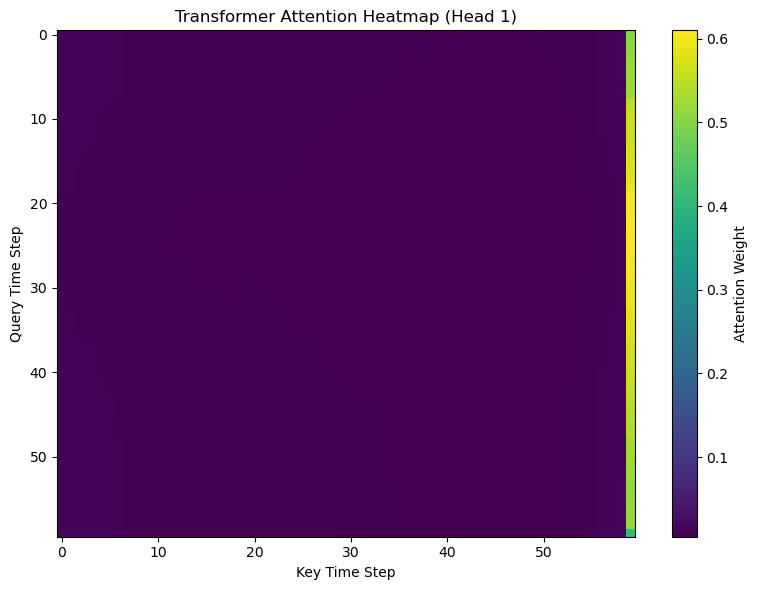

In [135]:
attention_matrix = (
    attention_weights[0,0]
    .cpu()
    .numpy()
)

plt.figure(figsize=(8,6))

plt.imshow(
    attention_matrix,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Attention Weight")

plt.title(
    "Transformer Attention Heatmap (Head 1)"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

## Average Multi-Head Attention
Since the Transformer employs four attention heads, the attention weights were averaged across all heads to obtain a global view of temporal importance.

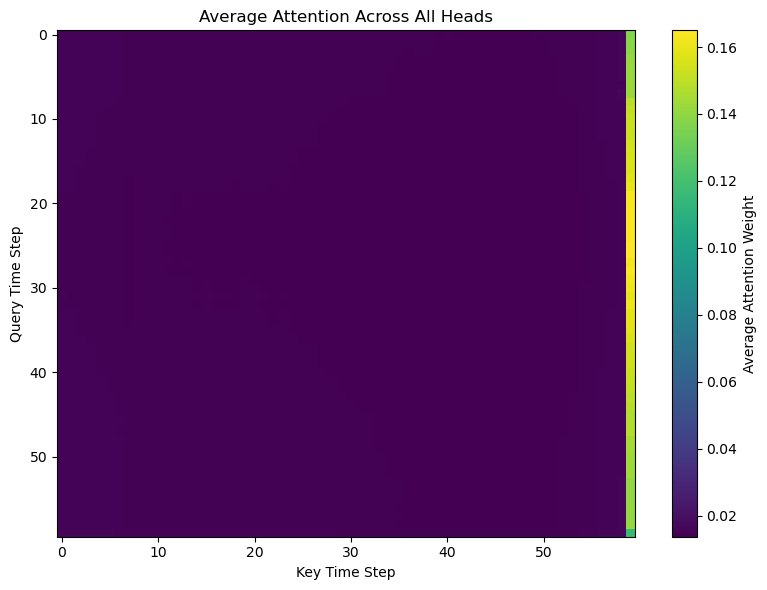

In [136]:
avg_attention = (
    attention_weights[0]
    .mean(dim=0)
    .cpu()
    .numpy()
)

plt.figure(figsize=(8,6))

plt.imshow(
    avg_attention,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Average Attention Weight")

plt.title(
    "Average Attention Across All Heads"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

In [140]:
print(attention_weights.shape)
print(avg_attention.shape)

torch.Size([1, 4, 60, 60])
(60, 60)


## Plot Attention Heatmap

## Historical Timestep Importance

In [141]:
importance_scores = avg_attention[-1]

top_k = 10

top_indices = np.argsort(
    importance_scores
)[-top_k:][::-1]

print("Top 10 Most Important Timesteps\n")

for rank, idx in enumerate(top_indices, start=1):

    print(
        f"Rank {rank}: "
        f"Timestep {idx} "
        f"(Importance = {importance_scores[idx]:.4f})"
    )

Top 10 Most Important Timesteps

Rank 1: Timestep 59 (Importance = 0.1162)
Rank 2: Timestep 58 (Importance = 0.0160)
Rank 3: Timestep 0 (Importance = 0.0157)
Rank 4: Timestep 1 (Importance = 0.0157)
Rank 5: Timestep 57 (Importance = 0.0157)
Rank 6: Timestep 2 (Importance = 0.0156)
Rank 7: Timestep 3 (Importance = 0.0156)
Rank 8: Timestep 56 (Importance = 0.0156)
Rank 9: Timestep 4 (Importance = 0.0155)
Rank 10: Timestep 5 (Importance = 0.0155)


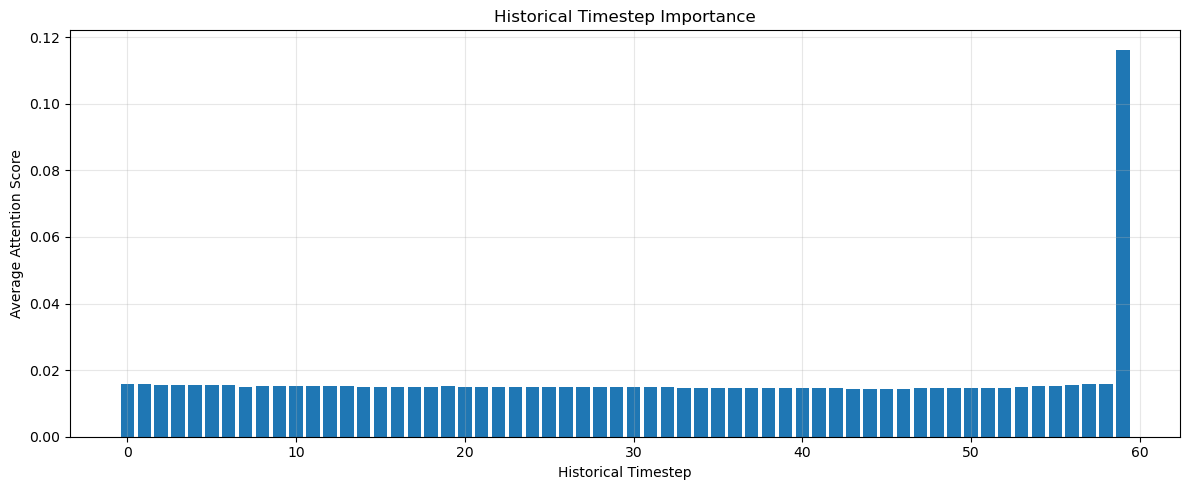

In [142]:
plt.figure(figsize=(12,5))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.title(
    "Historical Timestep Importance"
)

plt.xlabel("Historical Timestep")
plt.ylabel("Average Attention Score")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

## Uncertainty Quantification using Monte Carlo Dropout

##  TEQ: Uncertainty Quantification

This section evaluates the predictive uncertainty of the Transformer model using Monte Carlo Dropout. During inference, dropout remains active and multiple stochastic forward passes are performed. The resulting prediction distribution is used to estimate uncertainty, confidence intervals, and prediction reliability.

## Enable Monte Carlo Dropout


In [143]:
def enable_dropout(model):
    """
    Enable dropout layers during inference.
    """
    for module in model.modules():
        if module.__class__.__name__.startswith("Dropout"):
            module.train()

## Generate Monte Carlo Predictions

In [144]:
MC_SAMPLES = 100

model.eval()
enable_dropout(model)

mc_predictions = []

with torch.no_grad():

    for _ in range(MC_SAMPLES):

        preds = model(X_test_tensor.to(device))

        mc_predictions.append(
            preds.cpu().numpy()
        )

mc_predictions = np.array(mc_predictions)

print("MC Prediction Shape:")
print(mc_predictions.shape)

MC Prediction Shape:
(100, 27737, 1)


## Compute Mean Prediction and Uncertainty

In [145]:
prediction_mean = mc_predictions.mean(axis=0)

prediction_std = mc_predictions.std(axis=0)

print("Mean Shape:", prediction_mean.shape)
print("Std Shape :", prediction_std.shape)

Mean Shape: (27737, 1)
Std Shape : (27737, 1)


## Visualize Prediction Distribution

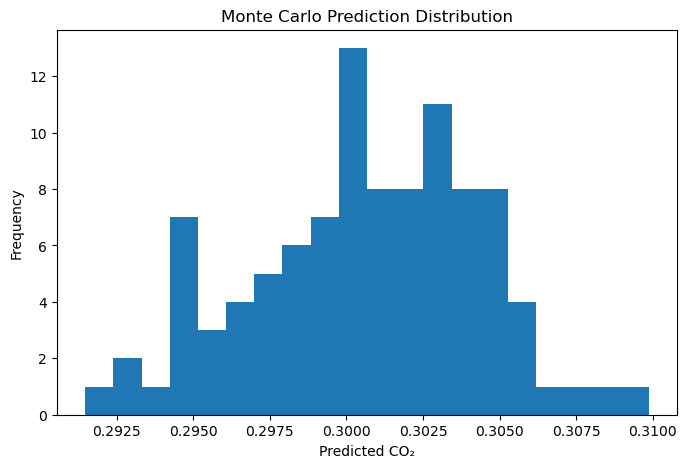

In [146]:
sample_idx = 0

plt.figure(figsize=(8,5))

plt.hist(
    mc_predictions[:, sample_idx, 0],
    bins=20
)

plt.xlabel("Predicted CO₂")
plt.ylabel("Frequency")
plt.title("Monte Carlo Prediction Distribution")

plt.show()

## Compute 95% Confidence Intervals

In [147]:
lower_bound = np.percentile(
    mc_predictions,
    2.5,
    axis=0
)

upper_bound = np.percentile(
    mc_predictions,
    97.5,
    axis=0
)

print(lower_bound.shape)
print(upper_bound.shape)

(27737, 1)
(27737, 1)


In [151]:
prediction_mean_original = y_scaler.inverse_transform(
    prediction_mean
)

lower_original = y_scaler.inverse_transform(
    lower_bound
)

upper_original = y_scaler.inverse_transform(
    upper_bound
)

y_test_original = y_scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

prediction_mean_original = prediction_mean_original.flatten()
lower_original = lower_original.flatten()
upper_original = upper_original.flatten()
y_test_original = y_test_original.flatten()

## Visualize Confidence Intervals

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

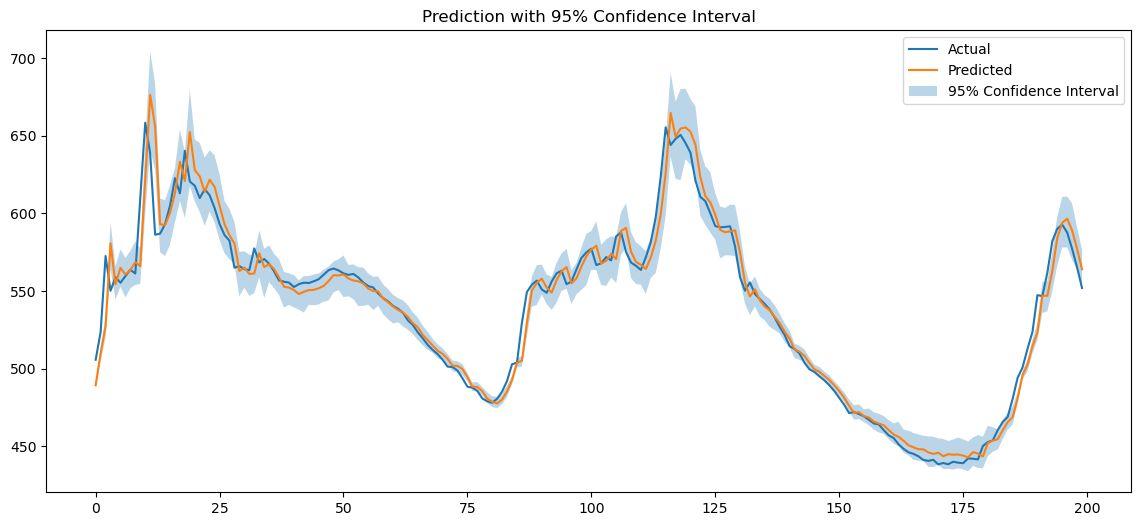

In [152]:
n_points = 200

plt.figure(figsize=(14,6))

plt.plot(
    y_test_original[:n_points],
    label="Actual"
)

plt.plot(
    prediction_mean_original[:n_points],
    label="Predicted"
)

plt.fill_between(
    np.arange(n_points),
    lower_original[:n_points],
    upper_original[:n_points],
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.legend()

plt.title("Prediction with 95% Confidence Interval")

plt.show()

## Coverage Probability

In [153]:
inside_interval = (
    (y_test_original >= lower_original)
    &
    (y_test_original <= upper_original)
)

coverage = inside_interval.mean() * 100

print(f"Coverage Probability: {coverage:.2f}%")

Coverage Probability: 90.77%


##  compute MPIW

In [157]:
mpiw = np.mean(
    upper_original - lower_original
)

print(f"MPIW: {mpiw:.2f}")

MPIW: 29.57


In [158]:
uq_results = pd.DataFrame({
    "Metric": [
        "Coverage Probability (%)",
        "MPIW"
    ],
    "Value": [
        coverage,
        mpiw
    ]
})

uq_results

,Metric,Value
0,Coverage Probability (%),90.774056
1,MPIW,29.574791
